## Objective
### Claim Outcome Classification 
- Business Purpose: Predict whether an insurance claim will be Paid, Pending, or Rejected before 
submission. 
- Define the target variable as claim_status. 
- Engineer financial and operational predictor features. 
- Perform a time-based train and test split. 
- Train baseline and advanced classification models. 
- Analyze class imbalance and mitigation strategy.

## ‼️ We will be using PyCaret only for this model. We have already demonstrated other skills in previous model construction

In [25]:
# ============================================================
# All Imports & Reproducibility Configuration
# ============================================================

import random
import os
import warnings

import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from data_profiling import ProfileReport
from pycaret.classification import *

# ============================================================
# Reproducibility — Single source of truth for all random seeds
# ============================================================
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

warnings.filterwarnings("ignore")

# Plot defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("All imports loaded. RANDOM_STATE =", RANDOM_STATE)

All imports loaded. RANDOM_STATE = 42


In [ ]:
# ============================================================
# Load Data
# ============================================================

DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])

# Sort by visit_date immediately — ensures temporal order for all downstream operations
df = df.sort_values("visit_date").reset_index(drop=True)

In [27]:
# All columns list
"""
patient_id                             int64
age                                    int64
gender                                object
city                                  object
insurance_provider                    object
chronic_flag                           int64
registration_date             datetime64[ns]
visit_id                               int64
visit_date                    datetime64[ns]
department                            object
visit_type                            object
length_of_stay_hours                 float64
risk_score                            object
doctor_id                              int64
bill_id                                int64
billed_amount                        float64
approved_amount                      float64
claim_status                          object
payment_days                         float64
billing_date                  datetime64[ns]
visit_frequency                        int64
avg_length_of_stay                   float64
days_since_registration                int64
total_billed                         float64
avg_payment_days                     float64
provider_rejection_rate              float64
doctor_rejection_rate                float64
visit_month                            int64
visit_day_of_week                      int64
visit_quarter                          int64
is_weekend                             int64
days_between_reg_and_visit             int64
billing_delay_days                     int64
"""

'\npatient_id                             int64\nage                                    int64\ngender                                object\ncity                                  object\ninsurance_provider                    object\nchronic_flag                           int64\nregistration_date             datetime64[ns]\nvisit_id                               int64\nvisit_date                    datetime64[ns]\ndepartment                            object\nvisit_type                            object\nlength_of_stay_hours                 float64\nrisk_score                            object\ndoctor_id                              int64\nbill_id                                int64\nbilled_amount                        float64\napproved_amount                      float64\nclaim_status                          object\npayment_days                         float64\nbilling_date                  datetime64[ns]\nvisit_frequency                        int64\navg_length_of_stay             

In [28]:
# "Lag Time" (the gap between treatment and billing). 
# Delays in filing often lead to claim rejections due to "timely filing" limits.
df["lag_time"] = (df["billing_date"] - df["visit_date"]).dt.days

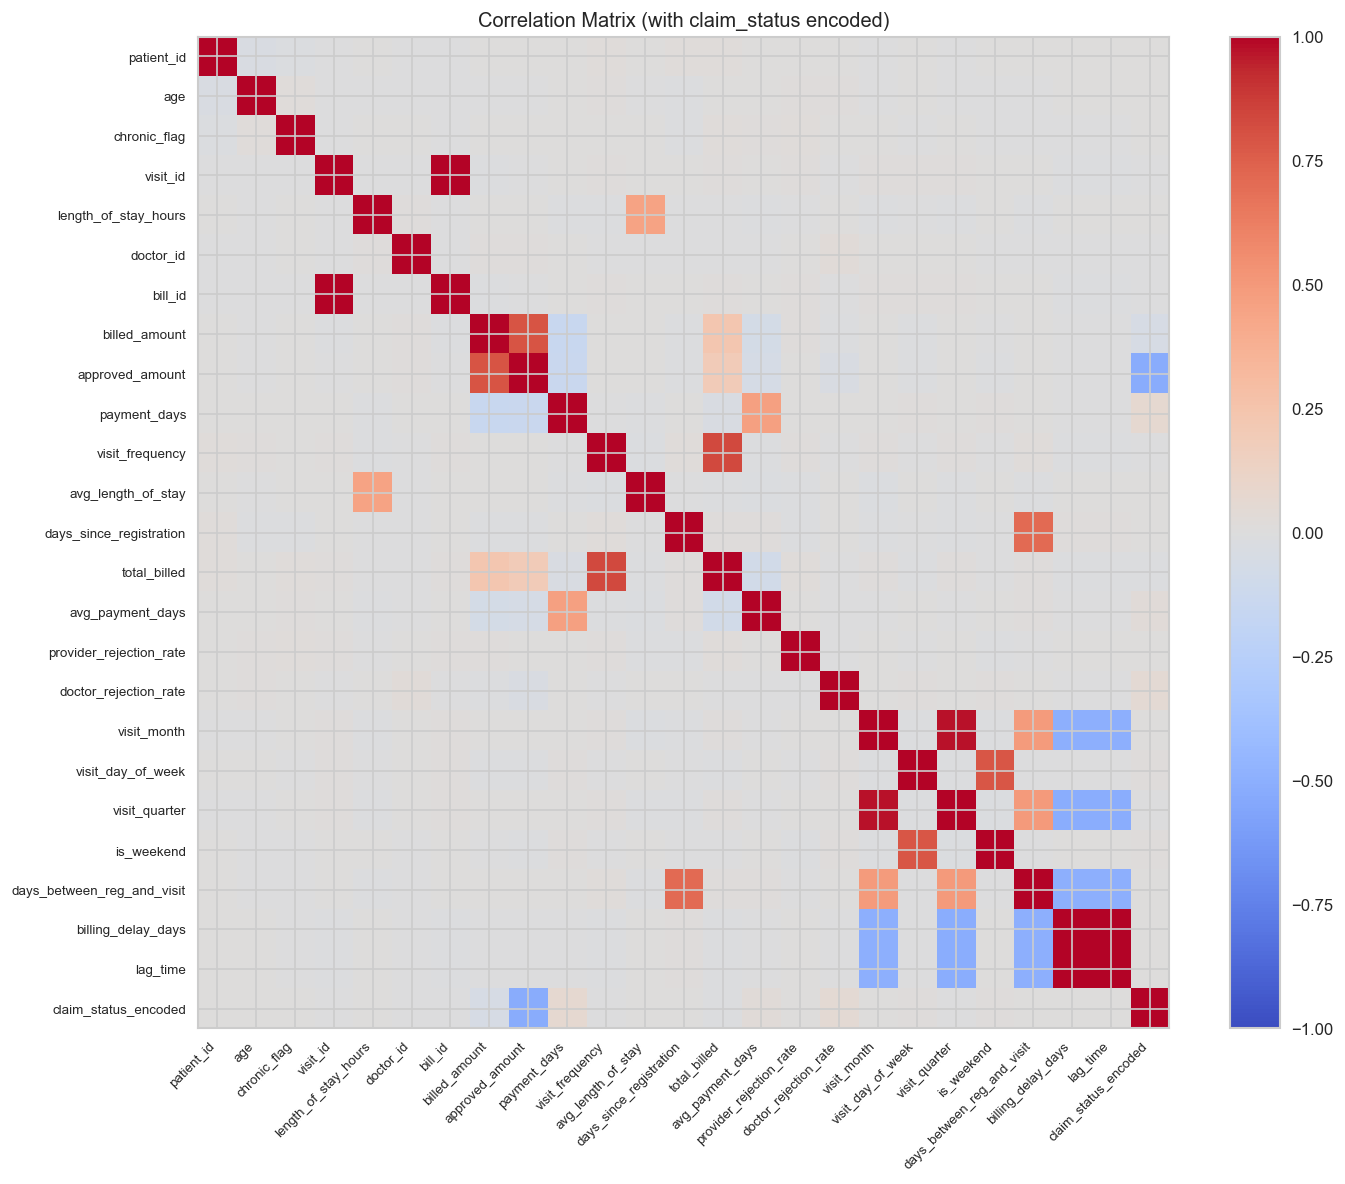


--- Correlation with claim_status ---
approved_amount              -0.519572
payment_days                  0.067441
doctor_rejection_rate         0.053586
billed_amount                -0.050157
avg_payment_days              0.030739
total_billed                 -0.014661
visit_day_of_week             0.011258
is_weekend                    0.010741
days_since_registration       0.007367
age                           0.007278
avg_length_of_stay            0.006915
visit_id                     -0.005888
bill_id                      -0.005888
doctor_id                    -0.005155
billing_delay_days            0.004621
lag_time                      0.004621
chronic_flag                  0.004470
visit_frequency              -0.002761
patient_id                    0.002075
provider_rejection_rate       0.002065
length_of_stay_hours          0.001695
visit_month                   0.000536
days_between_reg_and_visit    0.000440
visit_quarter                -0.000360


In [29]:
# Encode target variable for correlation
df_corr = df.select_dtypes(include=[np.number]).copy()
df_corr["claim_status_encoded"] = LabelEncoder().fit_transform(df["claim_status"])

corr_matrix = df_corr.corr()

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix (with claim_status encoded)")
plt.tight_layout()
plt.show()

# Show correlations with the target sorted by absolute value
print("\n--- Correlation with claim_status ---")
target_corr = corr_matrix["claim_status_encoded"].drop("claim_status_encoded").sort_values(key=abs, ascending=False)
print(target_corr.to_string())

Setting up the ML pipeline...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6881
[LightGBM] [Info] Number of data points in the train set: 31305, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

--- Target Classes ---
['Paid', 'Pending', 'Rejected']
Categories (3, object): ['Paid', 'Pending', 'Rejected']
Training models... This might take a few minutes.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.6321,0.0000,0.6321,0.5882,0.5802,0.2292,0.2570,2.3760
lightgbm,Light Gradient Boosting Machine,0.6285,0.6990,0.6285,0.5788,0.5778,0.2246,0.2489,1.8410
ada,Ada Boost Classifier,0.6197,0.0000,0.6197,0.5728,0.5773,0.2247,0.2411,1.0690
xgboost,Extreme Gradient Boosting,0.6211,0.6805,0.6211,0.5724,0.5760,0.2205,0.2392,1.0420
rf,Random Forest Classifier,0.6149,0.6757,0.6149,0.5659,0.5728,0.2146,0.2298,1.4950
et,Extra Trees Classifier,0.6114,0.6721,0.6114,0.5576,0.5645,0.1984,0.2154,1.2160
qda,Quadratic Discriminant Analysis,0.4933,0.0000,0.4933,0.5764,0.5125,0.1903,0.2033,1.0340
nb,Naive Bayes,0.4965,0.6622,0.4965,0.5694,0.5136,0.1858,0.1966,1.0110
knn,K Neighbors Classifier,0.4975,0.5944,0.4975,0.5063,0.5015,0.1140,0.1141,0.9640
dt,Decision Tree Classifier,0.4857,0.5619,0.4857,0.5043,0.4940,0.1077,0.1081,1.0270



--- Best Model Found ---
GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

Tuning hyperparameters for the best model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6257,0.0000,0.6257,0.5792,0.5820,0.2336,0.2524
1,0.6274,0.0000,0.6274,0.5833,0.5844,0.2364,0.2558
2,0.6326,0.0000,0.6326,0.5924,0.5926,0.2486,0.2673
3,0.6257,0.0000,0.6257,0.5858,0.5809,0.2326,0.2535
4,0.6331,0.0000,0.6331,0.5857,0.5886,0.2479,0.2681
5,0.6251,0.0000,0.6251,0.5845,0.5816,0.2266,0.2473
6,0.6411,0.0000,0.6411,0.5923,0.5938,0.2572,0.2807
7,0.6320,0.0000,0.6320,0.5855,0.5879,0.2485,0.2685
8,0.6217,0.0000,0.6217,0.5696,0.5722,0.2165,0.2379


Fitting 10 folds for each of 10 candidates, totalling 100 fits

--- Final Tuned Hyperparameters ---
{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.4,
 'loss': 'log_loss',
 'max_depth': 1,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.4,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 130,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 0.6,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

Generating evaluation plots...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.6281,0.6824,0.6281,0.5837,0.5863,0.2304,0.2474


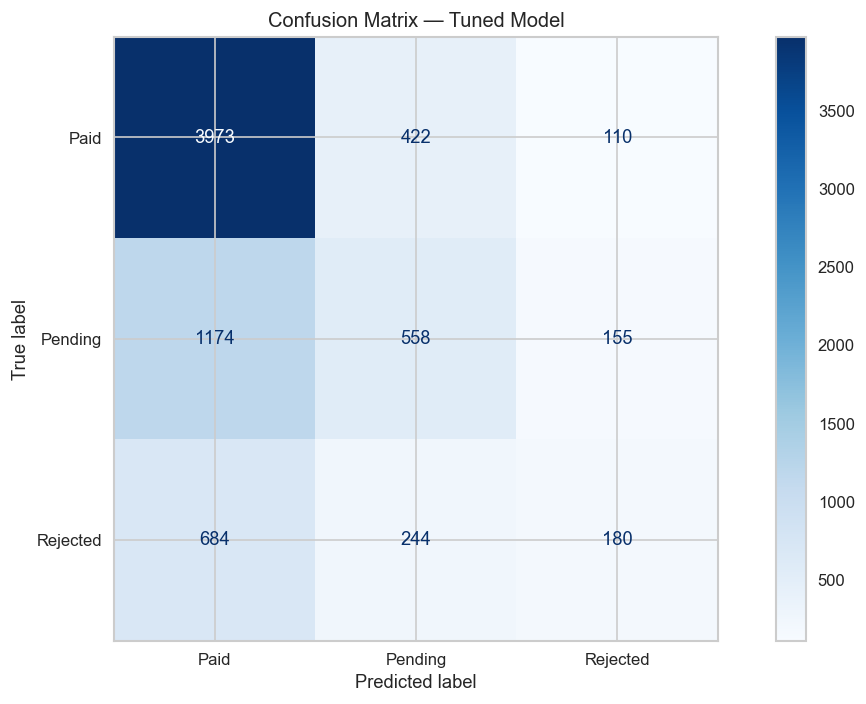

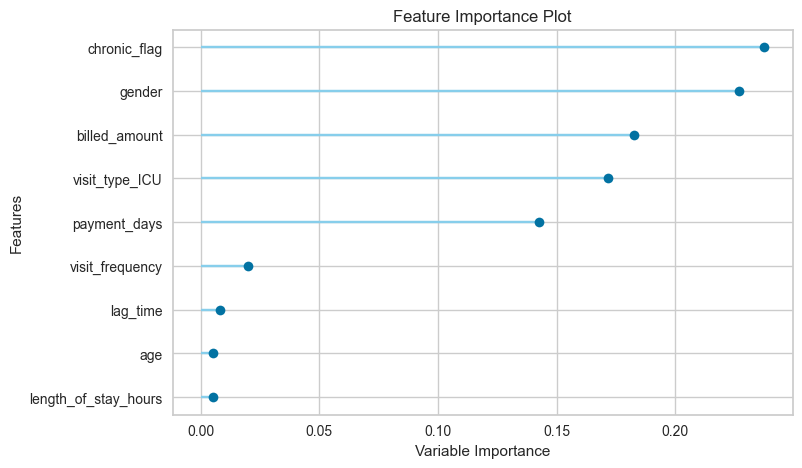

In [ ]:
print("Setting up the ML pipeline...")

columns_to_keep = [
    
                   # Essential for demographic profiling. 
                   # Certain age groups or genders may have different coverage limits or frequent claim types.
                    "age"
                   , "gender"

                    # Useful for identifying regional billing patterns or specific provider-insurer agreements in certain locations.
                   , "city"
                    #Critical. Claim approval logic varies significantly between different insurers. 
                    # Some may have stricter documentation requirements or lower approval rates for specific treatments.
                   , "insurance_provider"
                   #Patients with chronic conditions often have complex, recurring claims. 
                   # This is a strong indicator of whether a claim might be flagged for manual review or rejected based on 
                   # pre-existing condition clauses.
                   , "chronic_flag"

                    # (OPD, ER, ICU): High Importance. Emergency (ER) or Intensive Care (ICU) visits are high-stakes and high-cost, 
                    # often leading to more rigorous scrutiny from insurance providers compared to routine Outpatient (OPD) visits.
                    ,"visit_type"

                    # Helps identify if certain specialties
                    #  (e.g., Cardiology vs. General Medicine) have higher rejection rates due to the nature of the procedures.
                    , "department"

                    #A proxy for medical necessity. 
                    # Extremely short stays for expensive procedures, or unusually long stays, are often red flags for insurers.
                    , "length_of_stay_hours"
       
                    # Critical. Larger bills are statistically more likely to be audited, disputed, or partially rejected by insurers.
                    , "billed_amount"
                    , "lag_time"
                    # While this is a post-claim metric, in a training environment, historical patterns of how long a 
                    # provider takes to pay can correlate with the likelihood of an initial rejection or "Pending" status.
                    , "payment_days"
                    # Repeat patient, increase in billing amount, or risk scores
                    , "visit_frequency"
                   ]

columns_to_drop = [col for col in df.columns if col not in columns_to_keep and col != "claim_status"]


# df is already sorted by visit_date (done at load time) — no shuffling, no data leakage

# Aggressive SMOTE for minority classes (Pending, Rejected)
smote = SMOTE(sampling_strategy="not majority", random_state=RANDOM_STATE)

clf_setup = setup(
    data=df, 
    target="claim_status", 
    ignore_features=columns_to_drop,
    session_id=RANDOM_STATE,               # Keeps results reproducible
    train_size=0.8,              # Earliest 80% for training, latest 20% for testing
    data_split_shuffle=False,    # Preserves chronological order — test set = future data
    data_split_stratify=False,   # Stratification requires shuffle; disabled for time-based split
    fix_imbalance=True,          # Enable imbalance handling
    fix_imbalance_method=smote,  # Use SMOTE to oversample Pending & Rejected
    normalize=True,              # Scales numerical data
    feature_selection=True,      # Automatically drops weak features
    n_features_to_select=0.8,    # Keeps the top 80% of features
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    system_log=False,
    verbose=False
)


print("\n--- Target Classes ---")
print(get_config("y").unique())


# Train and Compare Models — optimize MCC to penalize bias toward majority class
print("Training models... This might take a few minutes.")
best_model = compare_models(sort="MCC")



print("\n--- Best Model Found ---")
print(best_model)

# Tune the Best Model — optimize MCC so Rejected/Pending aren't sacrificed
print("\nTuning hyperparameters for the best model...")
tuned_model = tune_model(best_model, optimize="MCC")

# Get best hyperparameters
print("\n--- Final Tuned Hyperparameters ---")

pprint.pprint(tuned_model.get_params())

# Visual Evaluation
print("\nGenerating evaluation plots...")



y_test = get_config("y_test")
y_pred = predict_model(tuned_model)["prediction_label"]

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=sorted(df["claim_status"].unique()), cmap="Blues")
plt.title("Confusion Matrix — Tuned Model")
plt.tight_layout()
plt.show()

plot_model(tuned_model, plot="feature") # See which health factors matter most